# Solar Generation in AIB Countries

This notebook quantifies solar power generation across AIB (Association of Issuing Bodies) member countries using ENTSO-E actual generation data, and compares it to Guarantee of Origin (GO) issuance volumes.

In [3]:
aib_members = [
    'AL', 'AT', 'BA', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 
    'EE', 'ES', 'FI', 'FR', 'GE', 'GR', 'HR', 'HU', 'IE', 'IS', 
    'IT', 'LT', 'LU', 'LV', 'ME', 'MK', 'NL', 'NO', 'PT', 'RO', 
    'RS', 'SE', 'SI', 'SK', 'UA', 'XK'
]

aib_electricity_scheme_group = [
    'AT', 'BE', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 
    'FR', 'GR', 'HR', 'HU', 'IE', 'IS', 'IT', 'LT', 'LU', 'LV', 
    'NL', 'NO', 'PT', 'RS', 'SE', 'SI', 'SK'
]

## Data Collection

We query the ENTSO-E solar production curves from the database. Each curve represents actual solar generation (MW) for a specific country/zone. The data is resampled to hourly granularity where needed, deduplicated by keeping the latest forecast revision, and aggregated per country. Unlike wind, solar generation has no onshore/offshore distinction, but some countries (IT, DK) report by bidding zone which must be summed to get a national total.

In [4]:
from kad_functions.sql_data import get_sql_query
import pandas as pd

# Hardcoded ENTSO-E solar production curve IDs per zone/country.
# Countries with bidding zones (NO, DK) or regions (IT) are listed by zone.
SOLAR_CURVE_IDS: dict[str, int | None] = {
    "AT": 1000318267,       # ENTSOE-APG-SOLAR-ACTUAL (national)
    "BE": 1000318269,       # ENTSOE-ELIA-SOLAR-ACTUAL (national)
    "CH": 910000230,        # EntsoE-ActualGeneration-CH-Solar
    "CY": None,
    "CZ": 910003004,        # ENTSOE_ActualGeneration_CZ_SOLAR__PROD
    "DE": 1000318266,       # ENTSOE-DE-SOLAR-ACTUAL (national)
    "DK1": 1000318272,      # ENTSOE-DK1-SOLAR-ACTUAL
    "DK2": 1000318273,      # ENTSOE-DK2-SOLAR-ACTUAL
    "EE": 1500028968,       # ENTSOE-POWER-PRODUCTION-ACTUAL-EE-SOLAR-MW
    "ES": 910000222,        # EntsoE-ActualGeneration-ES-Solar
    "FI": 1500019425,       # ENTSOE-POWER-PRODUCTION-ACTUAL-FI-SOLAR-MW
    "FR": 1000318270,       # ENTSOE-RTE-SOLAR-ACTUAL (national)
    "GR": 910003086,        # ENTSOE_ActualGeneration_GR_SOLAR__PROD
    "HR": 910004529,        # ENTSOE_ACTUAL-GENERATION_HR_SOLAR_PROD
    "HU": 1500027642,       # ENTSOE-POWER-PRODUCTION-ACTUAL-HU-SOLAR-MW
    "IS": None,
    "IT_NORTH": 910000286,  # EntsoE-ActualGeneration-IT-NORTH-Solar
    "IT_CNOR": 910000261,   # EntsoE-ActualGeneration-IT-CNOR-Solar
    "IT_CSOUTH": 910000272, # EntsoE-ActualGeneration-IT-CSOUTH-Solar
    "IT_SOUTH": 910000328,  # EntsoE-ActualGeneration-IT-SOUTH-Solar
    "IT_SICILY": 910000321, # EntsoE-ActualGeneration-IT-SICILY-Solar
    "IT_SARDINIA": 910000311, # EntsoE-ActualGeneration-IT-SARDINIA-Solar
    "IT_CALABRIA": 1500023508, # ENTSOE-POWER-PRODUCTION-IT-CALABRIA-SOLAR-MW
    "LT": 1500029107,       # ENTSOE-POWER-PRODUCTION-ACTUAL-LT-SOLAR-MW
    "LU": None,
    "LV": 1500029079,       # ENTSOE-POWER-PRODUCTION-ACTUAL-LV-SOLAR-MW
    "NL": 910000189,        # EntsoE-ActualGeneration-NL-Solar (national)
    "NO1": 1500026493,      # ENTSOE-POWER-PRODUCTION-ACTUAL-NO1-SOLAR-MW
    "NO2": 1500026535,      # ENTSOE-POWER-PRODUCTION-ACTUAL-NO2-SOLAR-MW
    "NO3": 1500026577,      # ENTSOE-POWER-PRODUCTION-ACTUAL-NO3-SOLAR-MW
    "NO4": 1500026619,      # ENTSOE-POWER-PRODUCTION-ACTUAL-NO4-SOLAR-MW
    "NO5": 1500026661,      # ENTSOE-POWER-PRODUCTION-ACTUAL-NO5-SOLAR-MW
    "PT": 910000343,        # EntsoE_ActualGeneration_PT_Solar_PROD
    "RS": None,             # No solar curve available
    "SE": 1500029521,       # ENTSOE-POWER-PRODUCTION-ACTUAL-SE-SOLAR-MW (national)
    "SI": 910003060,        # ENTSOE_ActualGeneration_SI_SOLAR__PROD
    "SK": 910003019,        # ENTSOE_ActualGeneration_SK_SOLAR__PROD
}

# Zone-to-country mapping for aggregation
zone_to_country = {
    'NO1': 'NO', 'NO2': 'NO', 'NO3': 'NO', 'NO4': 'NO', 'NO5': 'NO',
    'DK1': 'DK', 'DK2': 'DK',
    'IT_NORTH': 'IT', 'IT_CNOR': 'IT', 'IT_CSOUTH': 'IT', 'IT_SOUTH': 'IT',
    'IT_SICILY': 'IT', 'IT_SARDINIA': 'IT', 'IT_CALABRIA': 'IT',
}

# Build solar_curves DataFrame from the dictionary
records = []
for zone_or_country, curve_id in SOLAR_CURVE_IDS.items():
    if curve_id is None:
        continue
    country = zone_to_country.get(zone_or_country, zone_or_country)
    zone = zone_or_country if zone_or_country in zone_to_country else None
    records.append({
        'CurveId': curve_id,
        'CountryCode': country,
        'Zone': zone,
    })

solar_curves = pd.DataFrame(records)

print(f"Selected {len(solar_curves)} curves across {solar_curves['CountryCode'].nunique()} countries")
print(f"\nCountries: {sorted(solar_curves['CountryCode'].unique())}")
print(f"\nCurves per country:")
print(solar_curves.groupby('CountryCode').size().sort_index())

display(solar_curves)

Selected 33 curves across 22 countries

Countries: ['AT', 'BE', 'CH', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IT', 'LT', 'LV', 'NL', 'NO', 'PT', 'SE', 'SI', 'SK']

Curves per country:
CountryCode
AT    1
BE    1
CH    1
CZ    1
DE    1
DK    2
EE    1
ES    1
FI    1
FR    1
GR    1
HR    1
HU    1
IT    7
LT    1
LV    1
NL    1
NO    5
PT    1
SE    1
SI    1
SK    1
dtype: int64


,CurveId,CountryCode,Zone
0,1000318267,AT,None
1,1000318269,BE,None
2,910000230,CH,None
3,910003004,CZ,None
4,1000318266,DE,None
5,1000318272,DK,DK1
6,1000318273,DK,DK2
7,1500028968,EE,None
8,910000222,ES,None
9,1500019425,FI,None


In [5]:
available_solar_countries = sorted(solar_curves['CountryCode'].unique())

print("Countries with solar generation data:", available_solar_countries)
print("Number of countries with solar generation data:", len(available_solar_countries))
print("Countries without solar generation data:", sorted(set(aib_electricity_scheme_group) - set(available_solar_countries)))

Countries with solar generation data: ['AT', 'BE', 'CH', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'HU', 'IT', 'LT', 'LV', 'NL', 'NO', 'PT', 'SE', 'SI', 'SK']
Number of countries with solar generation data: 22
Countries without solar generation data: ['CY', 'IE', 'IS', 'LU', 'RS']


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def resample_generation_data(df, granularity='h'):
    df = df.resample('15min').ffill()
    df = df.resample(granularity).mean()
    return df

def get_curve_data(curve_id, granularity='h'):
    country_query = f"""
        SELECT ValueDateUTC, ForecastDateUTC, Value
        FROM pub.Timeseries1_v02
        WHERE CurveId = {curve_id}
        AND ValueDateUTC >= '2020-01-01'
    """

    data = get_sql_query(country_query)
    data = data.sort_values('ForecastDateUTC').drop_duplicates(subset='ValueDateUTC', keep='last')
    data['ValueDateUTC'] = pd.to_datetime(data['ValueDateUTC'])
    data = data.set_index('ValueDateUTC').sort_index()
    data = data.drop(columns=['ForecastDateUTC'])

    resampled = resample_generation_data(data['Value'], granularity=granularity)
    return resampled

solar_generation = {}

for country_code in available_solar_countries:
    curve_ids = solar_curves[solar_curves['CountryCode'] == country_code]['CurveId'].values

    if len(curve_ids) > 0:
        country_data = {}
        for curve_id in curve_ids:
            print(f"Fetching solar curve {curve_id} for {country_code}")
            country_data[curve_id] = get_curve_data(curve_id)
        solar_generation[country_code] = pd.DataFrame(country_data).sum(axis=1)

# Build DataFrame with countries as columns, hourly datetime as index
df_solar = pd.DataFrame(solar_generation)
df_solar = df_solar.dropna(axis=1, how='all')

print(f"\nSolar generation data: {df_solar.shape[1]} countries")
display(df_solar)

Fetching solar curve 1000318267 for AT
Fetching solar curve 1000318269 for BE
Fetching solar curve 910000230 for CH
Fetching solar curve 910003004 for CZ
Fetching solar curve 1000318266 for DE
Fetching solar curve 1000318272 for DK
Fetching solar curve 1000318273 for DK
Fetching solar curve 1500028968 for EE
Fetching solar curve 910000222 for ES
Fetching solar curve 1500019425 for FI
Fetching solar curve 1000318270 for FR
Fetching solar curve 910003086 for GR
Fetching solar curve 910004529 for HR
Fetching solar curve 1500027642 for HU
Fetching solar curve 910000286 for IT
Fetching solar curve 910000261 for IT
Fetching solar curve 910000272 for IT
Fetching solar curve 910000328 for IT
Fetching solar curve 910000321 for IT
Fetching solar curve 910000311 for IT
Fetching solar curve 1500023508 for IT
Fetching solar curve 1500029107 for LT
Fetching solar curve 1500029079 for LV
Fetching solar curve 910000189 for NL
Fetching solar curve 1500026493 for NO
Fetching solar curve 1500026535 for N

,AT,BE,CH,CZ,DE,DK,EE,ES,FI,FR,...,HU,IT,LT,LV,NL,NO,PT,SE,SI,SK
ValueDateUTC,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,0.0,0.00000,0.000000,0.0000,0.00000,0.00000,0.100,15.0,7.0000,0.0000,...,0.00000,0.00,0.000000,NaN,0.00000,NaN,0.0,NaN,0.000000,1.000
2020-01-01 01:00:00,0.0,0.00000,0.000000,0.0000,0.00000,0.00000,0.100,15.0,7.0000,0.0000,...,0.00000,1.00,0.000000,NaN,0.00000,NaN,0.0,NaN,0.000000,1.000
2020-01-01 02:00:00,0.0,0.00000,0.000000,0.0000,0.00000,0.00000,0.100,15.0,7.0000,0.0000,...,0.00000,0.00,0.000000,NaN,0.00000,NaN,0.0,NaN,0.000000,1.000
2020-01-01 03:00:00,0.0,0.00000,0.000000,0.0000,0.00000,0.00000,0.100,16.0,7.0000,0.0000,...,0.00000,0.00,0.000000,NaN,0.00000,NaN,0.0,NaN,0.000000,1.000
2020-01-01 04:00:00,0.0,0.00000,0.000000,0.0000,0.00000,0.00000,0.100,26.0,7.0000,0.0000,...,0.00000,0.00,0.000000,NaN,0.00000,NaN,0.0,NaN,0.000000,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-04 06:00:00,2752.0,989.57750,1253.830322,1618.3025,16676.11925,1010.68175,530.700,11324.0,688.1575,2903.6125,...,1560.85650,8750.25,1050.852241,1092.0,62.96350,5.564608,432.2,530.95025,542.283069,79.375
2026-06-04 07:00:00,3997.0,1488.12775,1811.077636,2273.3675,20908.30100,1179.08725,575.350,18662.0,801.8850,4844.6600,...,2198.17950,12524.00,1233.160077,1139.0,97.10250,5.957574,1103.3,778.38400,790.539372,135.575
2026-06-04 08:00:00,4843.0,1864.72800,2361.620605,2658.1700,20908.30100,1567.91475,583.050,21125.0,983.3875,6812.6200,...,2507.17225,15387.25,1259.427363,745.0,136.87300,4.011914,1525.6,989.67525,955.376019,175.450


## Solar Generation Overview

The following plot shows monthly average solar generation across the available AIB member countries. Solar generation exhibits strong seasonal patterns with peaks in summer months and troughs in winter, driven by irradiance levels and daylight hours.

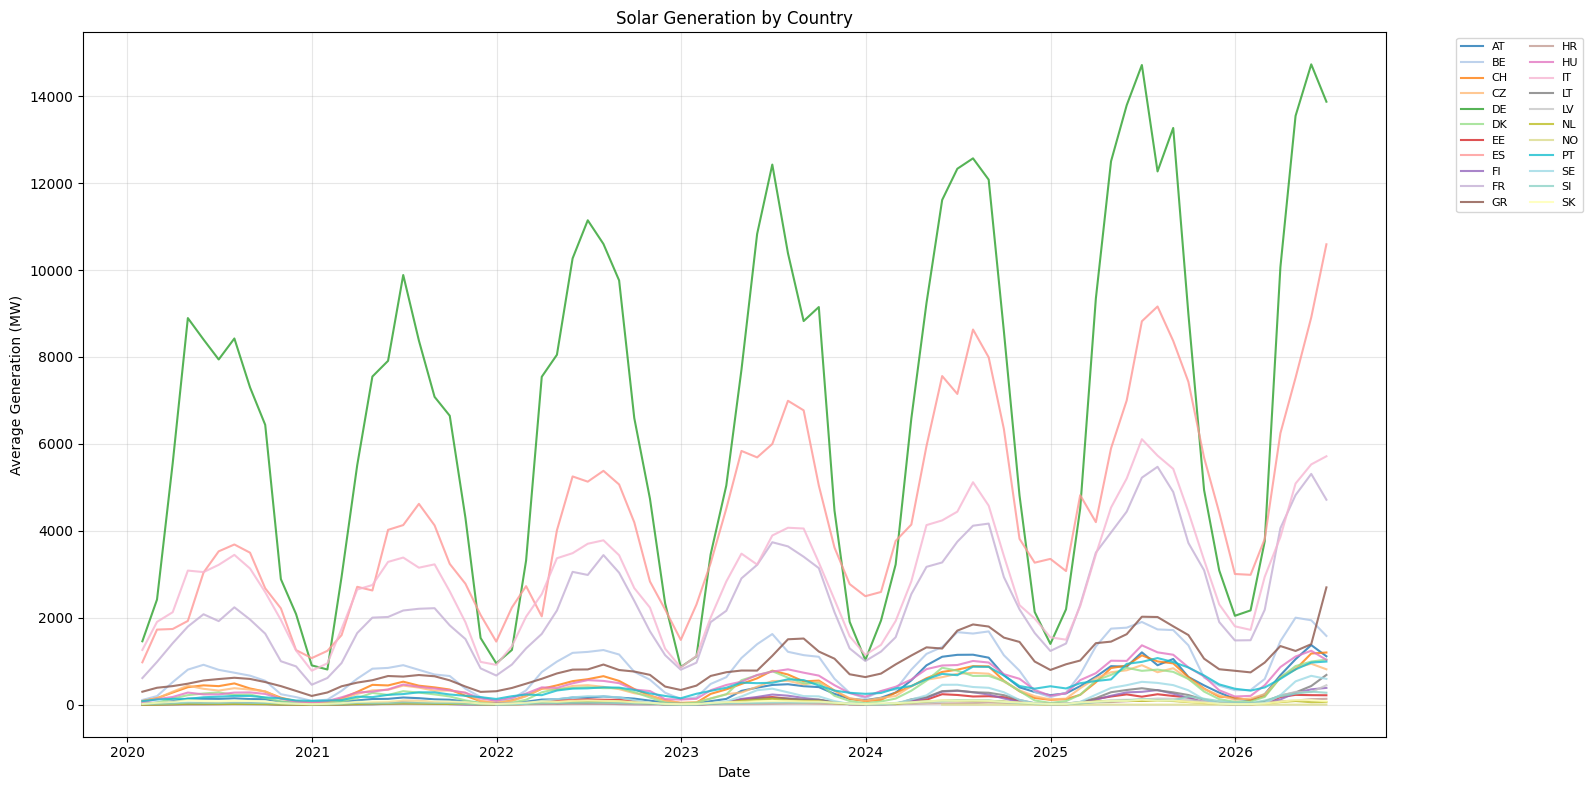

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# Assign consistent colors to all countries
all_countries = sorted(df_solar.columns)
_colors = (plt.cm.tab20.colors[:20] + plt.cm.Set3.colors[:7])
country_colors = {country: _colors[i % len(_colors)] for i, country in enumerate(all_countries)}

# Monthly average solar generation
monthly_solar = df_solar.resample('ME').mean()
for country in sorted(monthly_solar.columns):
    ax.plot(monthly_solar.index, monthly_solar[country], label=country, alpha=0.8, color=country_colors[country])
ax.set_xlabel('Date')
ax.set_ylabel('Average Generation (MW)')
ax.set_title('Solar Generation by Country')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison with GO Issuances

We compare ENTSO-E actual solar generation (converted to MWh) with GO issuance data from AIB statistics. The GO data is filtered for electricity certificates with solar as the energy source. Monthly generation is matched to monthly GO issuance by country.

In [8]:
import pandas as pd

path_1 = "/Users/kad/Library/CloudStorage/OneDrive-InCommoditiesAS/Data/GOs/GO_All_Statistics_1.csv"
df_1 = pd.read_csv(path_1, sep=",")

path_2 = "/Users/kad/Library/CloudStorage/OneDrive-InCommoditiesAS/Data/GOs/GO_All_Statistics_2.csv"
df_2 = pd.read_csv(path_2, sep=",")

df = pd.concat([df_1, df_2], ignore_index=True)

display(df)

,year_month_date,year,month_name,domain_name,energy_carrier,energy_source_name,energy_source_level1,energy_source_level2,production_technology_name,production_date_cancel,production_date_expire,production_date_issue,transaction_date_cancel,transaction_date_expire,transaction_date_export,transaction_date_import,transaction_date_issue,transaction_date_transfer,transaction_date_withdraw
0,2025-03-01,2025,March,PT - Portugal,EECS-Electricity,F01010101,Renewable,Renewable - Biomass,T050202,0,0,0,0,0,0,1134,0,0,0
1,2026-03-01,2026,March,CZ - Czech Republic,EECS-Electricity,F01030400,Renewable,Renewable - Biomass,T050500,0,0,0,1918,0,0,1918,0,0,0
2,2025-05-01,2025,May,FR - France,EECS-Electricity,F01010301,Renewable,Renewable - Biomass,T050301,5529,0,0,0,0,0,0,0,0,0
3,2023-03-01,2023,March,CZ - Czech Republic,EECS-Electricity,F01050100,Renewable,Renewable - Wind,T020000,59613,447,44798,92322,2238,27707,41757,44047,47886,0
4,2024-03-01,2024,March,FR - France,EECS-Electricity,F01030400,Renewable,Renewable - Biomass,T050502,0,0,0,2000,0,0,2000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114135,2022-12-01,2022,December,IT - Italy,EECS-Electricity,F01010101,Renewable,Renewable - Biomass,T050000,147307,0,128702,0,0,7254,263060,154040,10722,0
114136,2019-05-01,2019,May,NO - Norway,EECS-Electricity,F01050200,Renewable,Renewable - Hydro & Marine,T030000,2309808,40178,8019101,356688,817501,3432797,415589,7062114,984905,0
114137,2020-04-01,2020,April,AT - Austria,EECS-Electricity,F01030300,Renewable,Renewable - Biomass,T050501,0,0,0,357,0,0,0,0,0,0
114138,2022-02-01,2022,February,AT - Austria,EECS-Electricity,F01010300,Renewable,Renewable - Biomass,T050202,0,0,0,0,0,0,0,0,14626,0


In [9]:
go_df = df.copy()

# Only consider energy carrier electricity for now
go_df = go_df[go_df['energy_carrier'].str.contains('Electricity')]

# Calendar columns
go_df["month"] = go_df["year_month_date"].str.split("-").str[1].astype(int)
go_df["year"] = go_df["year"].astype(int)

go_df = go_df.drop(columns=["year_month_date", "month_name"])

# Classification columns
go_df['country_code'] = go_df['domain_name'].str.split(' ').str[0].astype(str)
go_df['energy_source_category'] = go_df['energy_source_level1'].astype(str)
go_df['energy_source'] = go_df['energy_source_level2'].str.split(' ').str[-1].astype(str)

go_df = go_df.drop(columns=['domain_name', 'energy_carrier', 'energy_source_name', 'energy_source_level1', 'energy_source_level2', 'production_technology_name'])

# Columns reordering
go_df = go_df[['year', 'month', 'country_code', 'energy_source_category', 'energy_source'] + go_df.columns[1:11].tolist()]

# Remove incomplete last month data
go_df = go_df[(go_df['year'] >= 2020) & ~((go_df['year'] == 2026) & (go_df['month'] == 4))]

display(go_df)

,year,month,country_code,energy_source_category,energy_source,production_date_cancel,production_date_expire,production_date_issue,transaction_date_cancel,transaction_date_expire,transaction_date_export,transaction_date_import,transaction_date_issue,transaction_date_transfer,transaction_date_withdraw
0,2025,3,PT,Renewable,Biomass,0,0,0,0,0,0,1134,0,0,0
1,2026,3,CZ,Renewable,Biomass,0,0,0,1918,0,0,1918,0,0,0
2,2025,5,FR,Renewable,Biomass,5529,0,0,0,0,0,0,0,0,0
3,2023,3,CZ,Renewable,Wind,59613,447,44798,92322,2238,27707,41757,44047,47886,0
4,2024,3,FR,Renewable,Biomass,0,0,0,2000,0,0,2000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114133,2021,11,DK,Renewable,Marine,46596,0,190,0,4673,1024,11840,233,0,0
114135,2022,12,IT,Renewable,Biomass,147307,0,128702,0,0,7254,263060,154040,10722,0
114137,2020,4,AT,Renewable,Biomass,0,0,0,357,0,0,0,0,0,0
114138,2022,2,AT,Renewable,Biomass,0,0,0,0,0,0,0,0,14626,0


In [10]:
# Filter GO data for solar only
solar_go = go_df[go_df['energy_source'] == 'Solar'].copy()

# Monthly GO issuance (MWh) by country
go_issued = solar_go.groupby(['year', 'month', 'country_code'])['production_date_issue'].sum().reset_index()
go_issued.columns = ['year', 'month', 'country_code', 'go_issued_mwh']
go_issued['date'] = pd.to_datetime(go_issued[['year', 'month']].assign(day=1))

# Monthly ENTSO-E generation (MW hourly -> MWh by summing hourly values)
monthly_gen_mwh = df_solar.resample('ME').sum()  # sum of hourly MW = MWh

# Reshape to long format for comparison
gen_long = monthly_gen_mwh.reset_index().melt(id_vars='ValueDateUTC', var_name='country_code', value_name='entsoe_mwh')
gen_long['year'] = gen_long['ValueDateUTC'].dt.year
gen_long['month'] = gen_long['ValueDateUTC'].dt.month

# Merge GO issuance with ENTSO-E generation
comparison = gen_long.merge(go_issued, on=['year', 'month', 'country_code'], how='outer')
comparison['date'] = pd.to_datetime(comparison[['year', 'month']].assign(day=1))
comparison = comparison.sort_values(['country_code', 'date'])

# GO issuance rate (% of generation that got GOs issued)
entsoe_safe = comparison['entsoe_mwh'].where(comparison['entsoe_mwh'] != 0)
comparison['go_rate'] = comparison['go_issued_mwh'] / entsoe_safe * 100

display(comparison[['date', 'country_code', 'entsoe_mwh', 'go_issued_mwh', 'go_rate']].dropna(subset=['entsoe_mwh', 'go_issued_mwh']))

,date,country_code,entsoe_mwh,go_issued_mwh,go_rate
0,2020-01-01,AT,19033.0,55671.0,292.497242
27,2020-02-01,AT,33513.0,63676.0,190.003879
55,2020-03-01,AT,60004.0,87981.0,146.625225
83,2020-04-01,AT,101515.0,121158.0,119.34985
111,2020-05-01,AT,102552.0,122324.0,119.279975
...,...,...,...,...,...
2097,2025-11-01,SK,17750.7,1538.0,8.664447
2127,2025-12-01,SK,10579.0,900.0,8.50742
2157,2026-01-01,SK,11582.0,891.0,7.692972
2186,2026-02-01,SK,19221.2,2047.0,10.649699


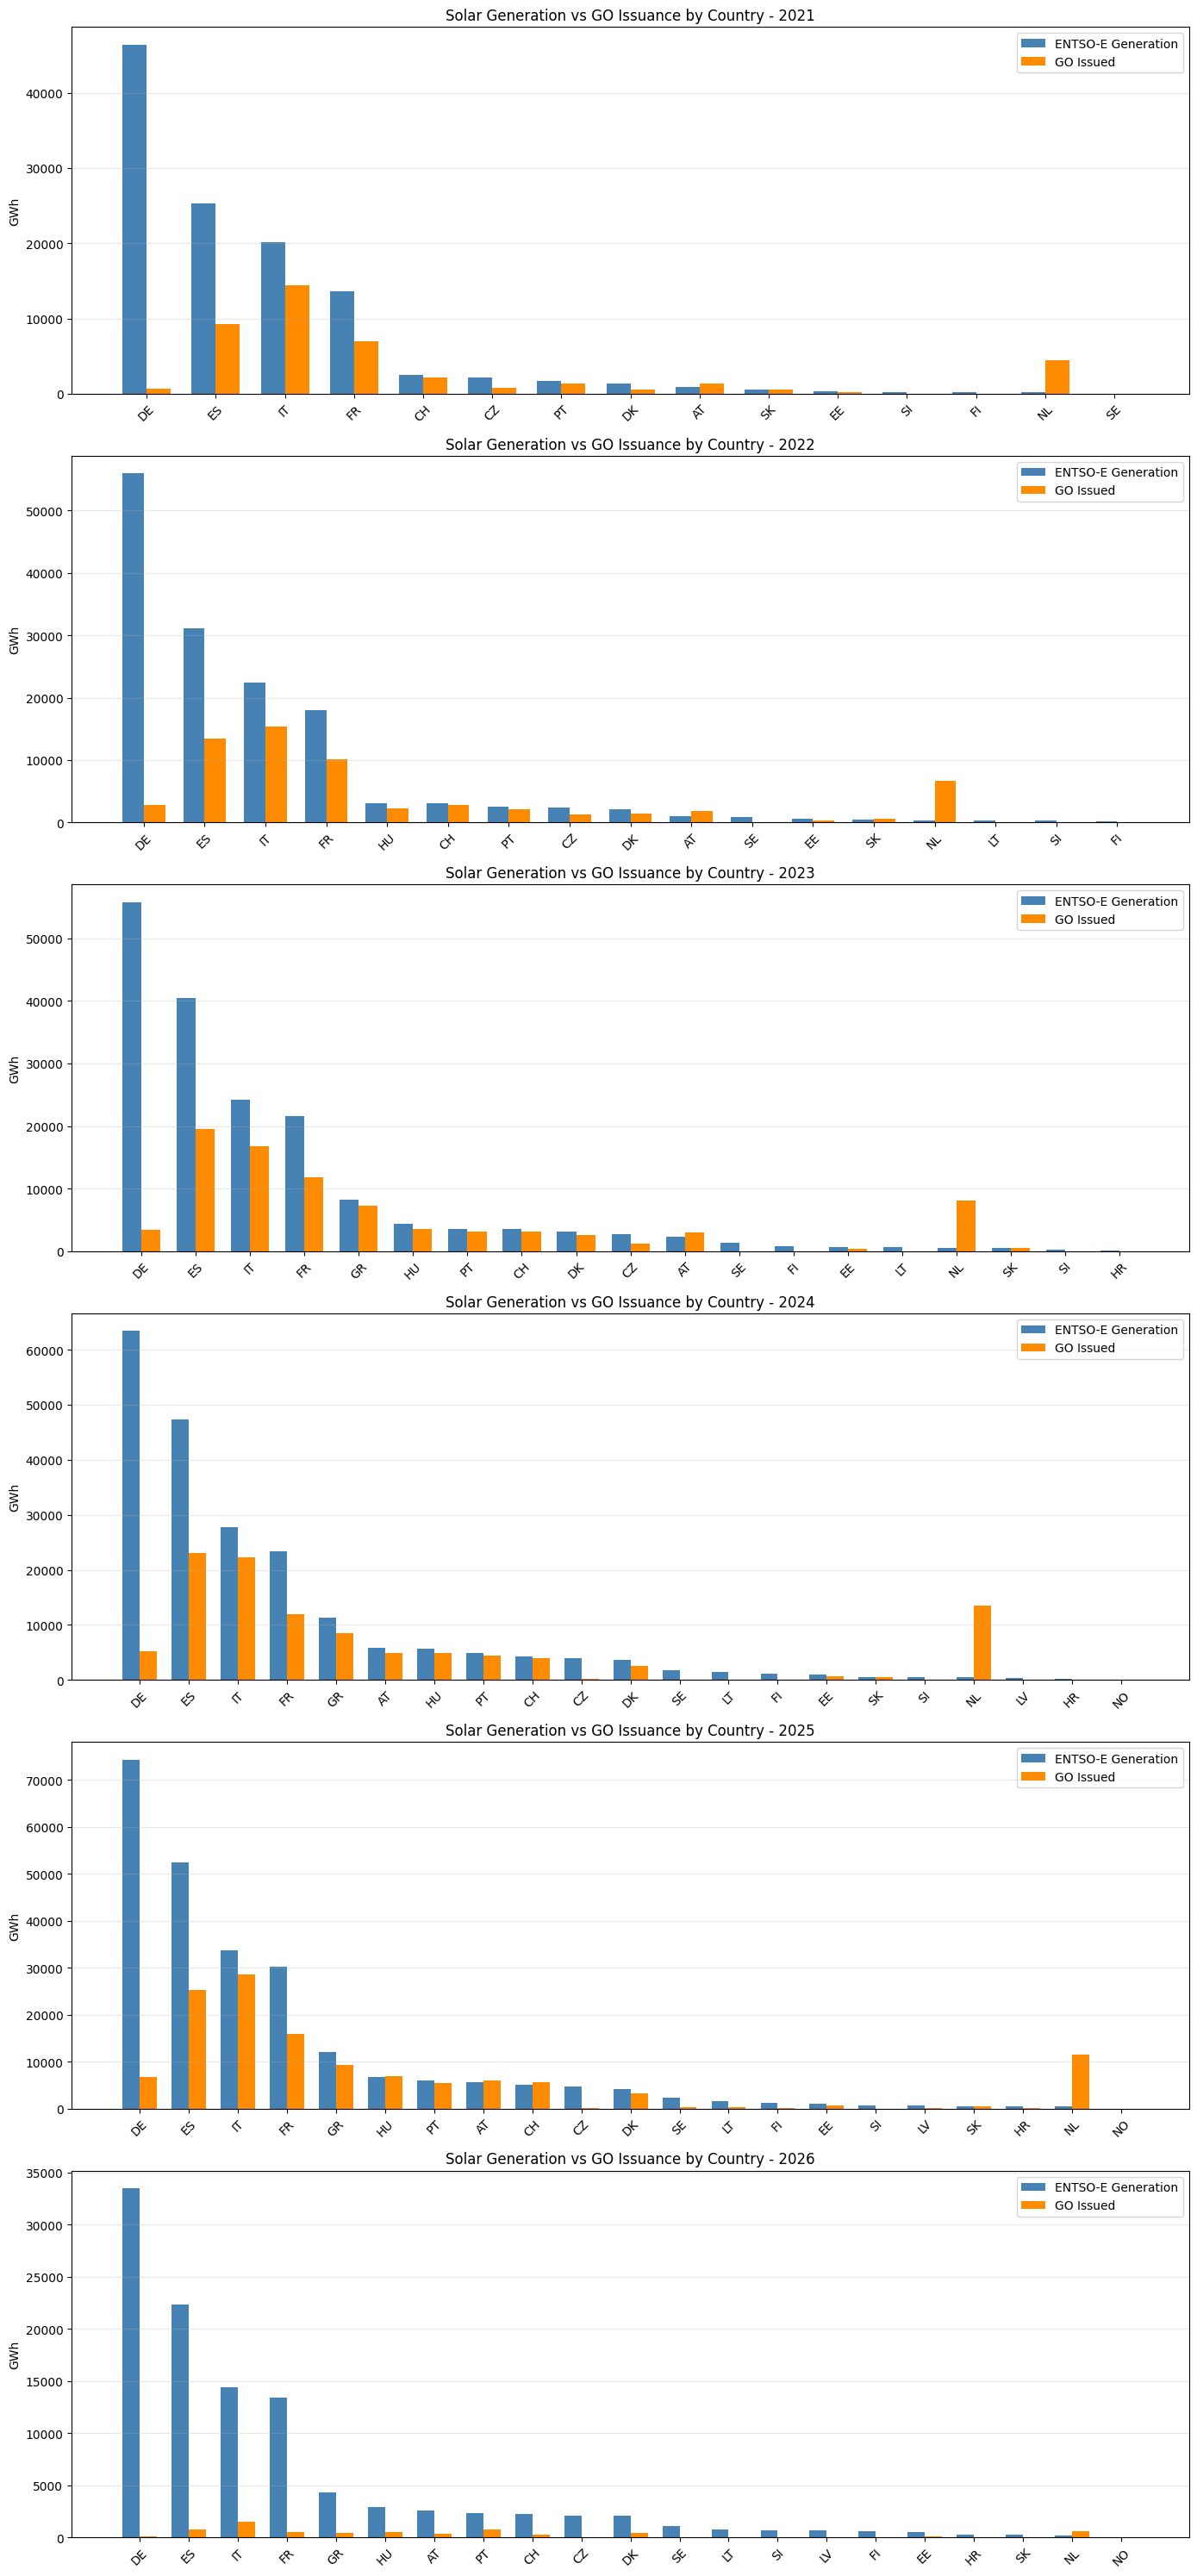

In [11]:
# Plot comparison: annual totals by country
annual = comparison.groupby(['country_code', comparison['date'].dt.year]).agg(
    entsoe_gwh=('entsoe_mwh', lambda x: x.sum() / 1e3),
    go_issued_gwh=('go_issued_mwh', lambda x: x.sum() / 1e3)
).reset_index()
annual.columns = ['country_code', 'year', 'entsoe_gwh', 'go_issued_gwh']

# Filter to countries present in both datasets and year 2021+
annual = annual[(annual['entsoe_gwh'] > 0) & (annual['go_issued_gwh'] > 0) & (annual['year'] >= 2021)]

# Plot per year
years = sorted(annual['year'].unique())
fig, axes = plt.subplots(len(years), 1, figsize=(14, 5 * len(years)))

for i, year in enumerate(years):
    ax = axes[i] if len(years) > 1 else axes
    year_data = annual[annual['year'] == year].sort_values('entsoe_gwh', ascending=False)
    
    x = range(len(year_data))
    width = 0.35
    ax.bar([p - width/2 for p in x], year_data['entsoe_gwh'], width, label='ENTSO-E Generation', color='steelblue')
    ax.bar([p + width/2 for p in x], year_data['go_issued_gwh'], width, label='GO Issued', color='darkorange')
    ax.set_xticks(list(x))
    ax.set_xticklabels(year_data['country_code'], rotation=45)
    ax.set_ylabel('GWh')
    ax.set_title(f'Solar Generation vs GO Issuance by Country - {year}')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Pending GO Issuance by Production Year

For each country, we compute a settled GO factor (sum of GOs issued / sum of ENTSO-E generation) over 2022–2024 — production years fully past the 12-month issuance window. Applying this benchmark to each year's ENTSO-E generation gives the expected total GO issuance per year; the difference vs. actual `production_date_issue` is the pending volume. By construction, 2022–2024 net to ~0; 2021 reflects how that year's coverage compares to the benchmark; 2025–2026 reflect timing-related pending issuance still within the window.

In [12]:
# Pending GO issuance per production year
# Approach: use 2022-2024 as "settled benchmark" years (fully past the 12-month issuance window).
# For each country, compute the aggregate GO factor (sum of production_date_issue / sum of ENTSO-E gen)
# over those years. Apply this factor to each year's ENTSO-E generation to get expected total GOs.
# Pending = expected - actual production_date_issue (clipped at 0, at the year aggregate).
# Note: by construction 2022-2024 net to ~0 pending. 2021 reflects how that year's coverage compares
# to the 2022-2024 average. 2025-2026 reflect timing-related pending issuance still within the window.

historical = annual[(annual['year'] >= 2021) & (annual['year'] <= 2025)].copy()

settled_factors = historical[historical['year'].between(2022, 2024)].groupby('country_code').apply(
    lambda g: g['go_issued_gwh'].sum() / g['entsoe_gwh'].sum()
)

print("Settled Solar GO Issuance Factor by Country (2022-2024 aggregate)")
print("Factor = sum(GO Issued) / sum(ENTSO-E Generation)")
print("=" * 65)
display(settled_factors.round(3).rename('settled_factor').to_frame())

pending_per_year = annual.copy()
pending_per_year['settled_factor'] = pending_per_year['country_code'].map(settled_factors)
pending_per_year['expected_go_gwh'] = pending_per_year['entsoe_gwh'] * pending_per_year['settled_factor']

# Aggregate first, then clip at the year level so countries with issued > expected (e.g. NL)
# offset countries with issued < expected, rather than being floored to zero per-country.
pending_by_year = pending_per_year.groupby('year').agg(
    entsoe_gwh=('entsoe_gwh', 'sum'),
    expected_gwh=('expected_go_gwh', 'sum'),
    issued_gwh=('go_issued_gwh', 'sum'),
).round(0)
pending_by_year['pending_gwh'] = (pending_by_year['expected_gwh'] - pending_by_year['issued_gwh']).clip(lower=0)
pending_by_year['pct_issued'] = (pending_by_year['issued_gwh'] / pending_by_year['expected_gwh'] * 100).round(1)

print(f"\nPending Solar GO issuance by production year")
print(f"(Benchmark: 2022-2024 settled GO factor per country, applied to each year's ENTSO-E generation)")
print("=" * 75)
display(pending_by_year)

Settled Solar GO Issuance Factor by Country (2022-2024 aggregate)
Factor = sum(GO Issued) / sum(ENTSO-E Generation)


/var/folders/9z/lz_ys39936g9hjq8wmdvgm080000gn/T/ipykernel_5433/528376927.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  settled_factors = historical[historical['year'].between(2022, 2024)].groupby('country_code').apply(


,settled_factor
country_code,
AT,1.062
CH,0.915
CZ,0.299
DE,0.066
DK,0.735
EE,0.633
ES,0.473
FI,0.034
FR,0.542



Pending Solar GO issuance by production year
(Benchmark: 2022-2024 settled GO factor per country, applied to each year's ENTSO-E generation)


,entsoe_gwh,expected_gwh,issued_gwh,pending_gwh,pct_issued
year,,,,,
2021,115702.0,47564.0,42895.0,4669.0,90.2
2022,144716.0,63882.0,61365.0,2517.0,96.1
2023,174967.0,86547.0,84735.0,1812.0,97.9
2024,209229.0,103081.0,107410.0,0.0,104.2
2025,245076.0,118605.0,127070.0,0.0,107.1
2026,107398.0,49919.0,6640.0,43279.0,13.3


## Conclusion

The comparison between ENTSO-E solar generation and GO issuance across AIB member countries reveals structural patterns similar to wind, but with some solar-specific characteristics:

**Germany (DE):** As with wind, Germany's GO issuance for solar is very low relative to its enormous installed solar capacity. The *Doppelvermarktungsverbot* (double marketing prohibition) under the EEG applies equally to solar — generators receiving feed-in tariffs or market premiums cannot obtain GOs. Since the vast majority of German rooftop and utility-scale solar was built under EEG support, these installations are excluded from the GO system. The gap is expected to narrow as older installations exit their 20-year support period.

**Netherlands (NL):** GO issuance may exceed ENTSO-E measured generation, as a significant share of Dutch solar capacity (particularly rooftop PV) is connected at the distribution level and invisible to ENTSO-E reporting, but fully eligible for GO issuance through VertiCer.

**Italy (IT):** As one of Europe's largest solar markets, Italy provides regional granularity through its bidding zone structure. The comparison between ENTSO-E data (summed across all zones) and GO issuance reveals the impact of Italy's incentive schemes on GO eligibility.

**Nordic countries (NO, SE, FI, DK):** Solar generation is comparatively small but growing. The match between generation and GO issuance tends to be close in well-functioning GO markets without double marketing restrictions.

**Southern European markets (ES, PT, GR):** These countries have high solar irradiance and growing capacity. The alignment between generation and GO issuance depends on the share of subsidised vs merchant capacity in each market.

**Smaller/Central European markets (AT, CH, CZ, HU, SI, SK, HR):** Generally show reasonable alignment between generation and GO issuance, with single-TSO countries providing complete national coverage.

**Pending GO issuance:** Like wind, solar GOs are typically issued in near-real time, driven by monthly PPA settlement cycles in the registries that dominate solar volumes (CNMC in ES, HKN in DE for the merchant share, VertiCer in NL, GME in IT). Against the 2022–2024 settled benchmark, 2025 solar production shows essentially no pending issuance by mid-2026 — virtually all GOs are already in the registry. Meaningful pending volume is concentrated in 2026 (production from the current year not yet processed).
